# Hybrid Lean Iterative Offset — Low-Resolution Diagnostic

Local sanity check (lat ×4, lon ×2) for the iterative self-calibrating offset idea.

**Idea:** start with scientific prior `lag1_lon_offset = 0.063`, fit the model, extract
`advec_lon_est`, set new offset = `|advec_lon_est|`, warm-start, repeat until
`|Δoffset| < tol`. Lag-2 offset is automatically `2 ×` via `multiplier=2.0`.

**Four models compared (all Hybrid Lean: A=20, B_local=8+fresh4, C_local=4+fresh3, total=41):**

| Model | Type | Init offset |
|---|---|---|
| `Irr_Baseline_A20_B18_C15` | local-only reference | — |
| `Hybrid_Lean_Fixed_0p063` | fixed offset | 0.063 |
| `Hybrid_Lean_Fixed_0p126` | fixed offset | 0.126 |
| `Hybrid_Lean_Iterative` | iterative self-calibrating | starts 0.063 |

True advec_lon cycled over `[-0.10, -0.16, -0.25]`.

In [1]:
import io
import contextlib
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.fft
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree

AMAREL_SRC = "/home/jl2815/tco"
LOCAL_SRC  = "/Users/joonwonlee/Documents/GEMS_TCO-1/src"
_src = AMAREL_SRC if os.path.exists(AMAREL_SRC) else LOCAL_SRC
sys.path.insert(0, _src)

from GEMS_TCO import kernels_vecchia
from GEMS_TCO import orderings as _orderings

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE  = torch.float64

# Low-resolution grid: lat ×4, lon ×2 (fast local testing)
DELTA_LAT = 0.044 * 4
DELTA_LON = 0.063 * 2
T_STEPS   = 8

print("DEVICE:", DEVICE)
print("SRC:",    _src)
print(f"Grid resolution: lat={DELTA_LAT:.3f}, lon={DELTA_LON:.3f}")

DEVICE: cpu
SRC: /Users/joonwonlee/Documents/GEMS_TCO-1/src
Grid resolution: lat=0.176, lon=0.126


## Settings

In [2]:
LAT_RANGE = (-3.0, 2.0)
LON_RANGE = (121.0, 131.0)
MC_NUM_ITERS = 10      # raise to 30+ for publication-quality results
SEED = 42

SMOOTH          = 0.5
MM_COND_NUMBER  = 100
NHEADS          = 0
DAILY_STRIDE    = 2

LBFGS_STEPS = 5
LBFGS_EVAL  = 20
LBFGS_HIST  = 10
INIT_NOISE  = 0.7
SUPPRESS_FIT_PRINTS = True

# Iterative offset calibration settings
MAX_OUTER_ITERS = 4
OFFSET_TOL      = 0.01    # stop when |Δoffset| < this
MIN_OFFSET      = 0.02    # floor to prevent collapse to 0

RUN_ONE_SHOT_GODAMBE = False
HESSIAN_EPS    = 1e-4
SCORE_EPS      = 1e-5
H_RIDGE_SCALE  = 1e-6
GODAMBE_J_METHOD         = "block"
GODAMBE_BLOCK_LAT_WIDTH  = 0.50
GODAMBE_BLOCK_LON_WIDTH  = 0.50
GODAMBE_BLOCK_TIME_WIDTH = 2.0

BASE_TRUE_DICT = {
    "sigmasq":    10.0,
    "range_lat":  0.5,
    "range_lon":  0.6,
    "range_time": 2.5,
    "advec_lat":  0.08,
    "nugget":     1.2,
}
TRUE_ADVEC_LON_LIST  = [-0.10, -0.16, -0.25]
DEFAULT_TRUE_ADVEC_LON = -0.16


def make_true_dict(advec_lon):
    return {**BASE_TRUE_DICT, "advec_lon": float(advec_lon)}


print(f"lon cell = {DELTA_LON:.3f}")
print(f"true advec_lon values: {TRUE_ADVEC_LON_LIST}")
print(f"iterative: max_outer_iters={MAX_OUTER_ITERS}, tol={OFFSET_TOL}, min_offset={MIN_OFFSET}")

lon cell = 0.126
true advec_lon values: [-0.1, -0.16, -0.25]
iterative: max_outer_iters=4, tol=0.01, min_offset=0.02


## Model Specs

In [3]:
BASE_A = 20


def total_cond_std(a, b, c):
    return int(a) + int(1 + b) + int(1 + c)


def total_cond_hybrid(a, b_local, b_fresh, c_local, c_fresh):
    return int(a) + int(1 + b_local + b_fresh) + int(1 + c_local + c_fresh)


def build_model_specs():
    specs = [
        {
            "name":                  "Irr_Baseline_A20_B18_C15",
            "group":                 "local_baseline",
            "kernel":                "std",
            "limit_A":               20, "limit_B": 18, "limit_C": 15,
            "lag1_local_count":      18, "lag1_fresh_count": 0,
            "lag2_local_count":      15, "lag2_fresh_count": 0,
            "pred_lag1_lon_offset":  0.0,
            "iterative":             False,
            "total_conditioning":    total_cond_std(20, 18, 15),
        },
        {
            "name":                  "Hybrid_Lean_Fixed_0p063",
            "group":                 "hybrid_lean_fixed",
            "kernel":                "hybrid_fresh",
            "limit_A":               20, "limit_B": 8, "limit_C": 4,
            "lag1_local_count":      8,  "lag1_fresh_count": 4,
            "lag2_local_count":      4,  "lag2_fresh_count": 3,
            "pred_lag1_lon_offset":  0.063,
            "iterative":             False,
            "total_conditioning":    total_cond_hybrid(20, 8, 4, 4, 3),
        },
        {
            "name":                  "Hybrid_Lean_Fixed_0p126",
            "group":                 "hybrid_lean_fixed",
            "kernel":                "hybrid_fresh",
            "limit_A":               20, "limit_B": 8, "limit_C": 4,
            "lag1_local_count":      8,  "lag1_fresh_count": 4,
            "lag2_local_count":      4,  "lag2_fresh_count": 3,
            "pred_lag1_lon_offset":  0.126,
            "iterative":             False,
            "total_conditioning":    total_cond_hybrid(20, 8, 4, 4, 3),
        },
        {
            "name":                  "Hybrid_Lean_Iterative",
            "group":                 "hybrid_lean_iterative",
            "kernel":                "hybrid_fresh",
            "limit_A":               20, "limit_B": 8, "limit_C": 4,
            "lag1_local_count":      8,  "lag1_fresh_count": 4,
            "lag2_local_count":      4,  "lag2_fresh_count": 3,
            "pred_lag1_lon_offset":  0.063,   # initial prior
            "iterative":             True,
            "total_conditioning":    total_cond_hybrid(20, 8, 4, 4, 3),
        },
    ]
    return {s["name"]: s for s in specs}


MODEL_SPECS = build_model_specs()
spec_df = pd.DataFrame(MODEL_SPECS).T
display(spec_df[[
    "group", "kernel", "limit_A",
    "lag1_local_count", "lag1_fresh_count",
    "lag2_local_count", "lag2_fresh_count",
    "pred_lag1_lon_offset", "iterative", "total_conditioning",
]])

,group,kernel,limit_A,lag1_local_count,lag1_fresh_count,lag2_local_count,lag2_fresh_count,pred_lag1_lon_offset,iterative,total_conditioning
Irr_Baseline_A20_B18_C15,local_baseline,std,20,18,0,15,0,0.0,False,55
Hybrid_Lean_Fixed_0p063,hybrid_lean_fixed,hybrid_fresh,20,8,4,4,3,0.063,False,41
Hybrid_Lean_Fixed_0p126,hybrid_lean_fixed,hybrid_fresh,20,8,4,4,3,0.126,False,41
Hybrid_Lean_Iterative,hybrid_lean_iterative,hybrid_fresh,20,8,4,4,3,0.063,True,41


## Hybrid Fresh Kernel Class

In [4]:
class fit_vecchia_lbfgs_fresh_hybrid(kernels_vecchia.fit_vecchia_lbfgs):
    """Local lag NN + fresh shifted-center lag NN at each lag step.

    Lag-k offset = k × lag1_lon_offset  (via multiplier=k in _build_shift_lookup).
    """

    def __init__(self, smooth, input_map, nns_map, mm_cond_number, nheads,
                 limit_A=20, limit_B=8, limit_C=4, daily_stride=2,
                 spatial_coords=None, lag1_lon_offset=0.063,
                 lag1_fresh_count=4, lag2_fresh_count=3):
        super().__init__(smooth, input_map, nns_map, mm_cond_number, nheads,
                         limit_A=limit_A, limit_B=limit_B, limit_C=limit_C,
                         daily_stride=daily_stride)
        self.spatial_coords   = spatial_coords
        self.lag1_lon_offset  = float(abs(lag1_lon_offset))
        self.lag1_fresh_count = int(lag1_fresh_count)
        self.lag2_fresh_count = int(lag2_fresh_count)

    def _spatial_coords_np(self, n_points):
        if self.spatial_coords is not None:
            coords_np = np.asarray(self.spatial_coords[:n_points], dtype=np.float64)
        else:
            all_data = [torch.from_numpy(d) if isinstance(d, np.ndarray) else d
                        for d in self.input_map.values()]
            coords_np = all_data[0][:n_points, :2].cpu().numpy().astype(np.float64)
        coords_np = coords_np.copy()
        coords_np[np.isnan(coords_np).any(axis=1)] = [0.0, 1000.0]
        return coords_np

    def _build_shift_lookup(self, n_points, multiplier):
        coords_np = self._spatial_coords_np(n_points)
        tree  = BallTree(np.radians(coords_np), metric="haversine")
        lats  = coords_np[:, 0]
        lons  = coords_np[:, 1]
        valid = ~np.isnan(coords_np).any(axis=1)
        lon_min, lon_max = float(np.nanmin(lons[valid])), float(np.nanmax(lons[valid]))
        target_lons = lons + multiplier * self.lag1_lon_offset
        outside = (~valid) | (target_lons < lon_min) | (target_lons > lon_max)
        _, idx = tree.query(np.column_stack([np.radians(lats), np.radians(target_lons)]), k=1)
        lookup = idx.flatten().astype(np.int64)
        lookup[outside] = np.arange(n_points, dtype=np.int64)[outside]
        return lookup

    def precompute_conditioning_sets(self):
        limit_A    = int(self.limit_A)
        lag1_local = int(self.limit_B)
        lag2_local = int(self.limit_C)
        lag1_fresh = int(self.lag1_fresh_count)
        lag2_fresh = int(self.lag2_fresh_count)
        daily_stride = int(self.daily_stride)

        max_dim_A   = limit_A
        max_dim_AB  = limit_A + 1 + lag1_local + lag1_fresh
        max_dim_ABC = max_dim_AB + 1 + lag2_local + lag2_fresh

        n_stored = next((len(m) for m in self.nns_map if len(m) > 0), 0)
        print(
            f"PrecompFreshHybrid "
            f"[A={max_dim_A},AB={max_dim_AB},ABC={max_dim_ABC} "
            f"B=local{lag1_local}+fresh{lag1_fresh} "
            f"C=local{lag2_local}+fresh{lag2_fresh} "
            f"offset={self.lag1_lon_offset:.4f} stored={n_stored}]",
            end=" ",
        )

        all_data_list = [torch.from_numpy(d) if isinstance(d, np.ndarray) else d
                         for d in self.input_map.values()]
        Real_Data = torch.cat(all_data_list, dim=0).to(self.device, dtype=torch.float32)
        n_real, num_cols = Real_Data.shape

        is_nan_real   = torch.isnan(Real_Data[:, 2])
        valid_lats    = Real_Data[~is_nan_real, 0]
        self.lat_mean_val = (valid_lats.mean().item() if valid_lats.numel() > 0
                             else Real_Data[:, 0].mean().item())
        is_nan_mask_np = is_nan_real.cpu().numpy()

        n_dummies  = max_dim_ABC
        dummy_block = torch.zeros((n_dummies, num_cols), device=self.device, dtype=torch.float32)
        for k in range(n_dummies):
            dummy_block[k, 0] = (k + 1) * 1e8
            dummy_block[k, 1] = (k + 1) * 1e8
            dummy_block[k, 3] = (k + 1) * 1e8
        Full_Data      = torch.cat([Real_Data, dummy_block], dim=0)
        dummy_start    = n_real
        is_nan_mask_np = np.append(is_nan_mask_np, np.zeros(n_dummies, dtype=bool))

        key_list       = list(self.input_map.keys())
        day_lengths    = [len(d) for d in all_data_list]
        cumulative_len = np.cumsum([0] + day_lengths)
        use_set_C      = daily_stride < len(key_list)
        n_pts_per_day  = day_lengths[0]

        lag1_center = self._build_shift_lookup(n_pts_per_day, multiplier=1.0)
        lag2_center = self._build_shift_lookup(n_pts_per_day, multiplier=2.0)

        heads_indices = []
        batch_list_A, batch_list_AB, batch_list_ABC = [], [], []

        def add_valid(indices, current, cap):
            count = 0
            for idx in indices:
                if count >= cap:
                    break
                idx = int(idx)
                if idx not in current and not is_nan_mask_np[idx]:
                    current.append(idx)
                    count += 1

        for time_idx, key in enumerate(key_list):
            day_len = day_lengths[time_idx]
            offset  = cumulative_len[time_idx]
            for local_idx in range(min(day_len, self.nheads)):
                idx = offset + local_idx
                if not is_nan_mask_np[idx]:
                    heads_indices.append(idx)
            if self.nheads >= day_len:
                continue

            for local_idx in range(self.nheads, day_len):
                target_idx = offset + local_idx
                if is_nan_mask_np[target_idx]:
                    continue
                current = []
                nbs = (self.nns_map[local_idx] if local_idx < len(self.nns_map)
                       else np.array([], dtype=np.int64))
                add_valid((offset + nbs).tolist(), current, cap=limit_A)

                has_B = time_idx > 0
                has_C = time_idx >= daily_stride

                if has_B:
                    prev_off = cumulative_len[time_idx - 1]
                    prev_len = day_lengths[time_idx - 1]
                    if local_idx < prev_len:
                        add_valid([prev_off + local_idx], current, cap=1)
                    local_cands = [prev_off + int(v) for v in nbs
                                   if int(v) < prev_len and int(v) != local_idx]
                    add_valid(local_cands, current, cap=lag1_local)
                    cb = int(lag1_center[local_idx]) if local_idx < len(lag1_center) else local_idx
                    if cb >= prev_len: cb = local_idx
                    nbs_b = (self.nns_map[cb] if cb < len(self.nns_map) else np.array([], dtype=np.int64))
                    fresh_b = [prev_off + cb] + [prev_off + int(v) for v in nbs_b
                                                  if int(v) < prev_len and int(v) != local_idx]
                    add_valid(fresh_b, current, cap=lag1_fresh)

                if has_C:
                    pd_idx = time_idx - daily_stride
                    pd_off = cumulative_len[pd_idx]
                    pd_len = day_lengths[pd_idx]
                    if local_idx < pd_len:
                        add_valid([pd_off + local_idx], current, cap=1)
                    local_cands = [pd_off + int(v) for v in nbs
                                   if int(v) < pd_len and int(v) != local_idx]
                    add_valid(local_cands, current, cap=lag2_local)
                    cc = int(lag2_center[local_idx]) if local_idx < len(lag2_center) else local_idx
                    if cc >= pd_len: cc = local_idx
                    nbs_c = (self.nns_map[cc] if cc < len(self.nns_map) else np.array([], dtype=np.int64))
                    fresh_c = [pd_off + cc] + [pd_off + int(v) for v in nbs_c
                                               if int(v) < pd_len and int(v) != local_idx]
                    add_valid(fresh_c, current, cap=lag2_fresh)

                if has_C:   max_d, tlist = max_dim_ABC, batch_list_ABC
                elif has_B: max_d, tlist = max_dim_AB,  batch_list_AB
                else:       max_d, tlist = max_dim_A,   batch_list_A

                n_valid = len(current)
                row = ([dummy_start + k for k in range(max_d - n_valid)] + current
                       if n_valid < max_d else current[-max_d:])
                tlist.append(row)

        heads_tensor = torch.tensor(heads_indices, device=self.device, dtype=torch.long)
        self.Heads_data = (
            Full_Data[heads_tensor].contiguous().to(torch.float64)
            if len(heads_indices) > 0
            else torch.empty((0, num_cols), device=self.device, dtype=torch.float64)
        )

        def build_tensors(idx_list, max_d):
            if not idx_list:
                return None, None, None, None, None
            T    = torch.tensor(idx_list, device=self.device, dtype=torch.long)
            G    = Full_Data[T]
            X    = G[..., [0, 1, 3]].contiguous().to(torch.float64)
            Y    = G[..., 2].unsqueeze(-1).contiguous().to(torch.float64)
            ones = torch.ones_like(G[..., 0]).unsqueeze(-1)
            lat  = (G[..., 0] - self.lat_mean_val).unsqueeze(-1)
            Locs = torch.cat([ones, lat, G[..., 4:11]], dim=-1).contiguous().to(torch.float64)
            is_dummy = (T >= dummy_start).unsqueeze(-1)
            Locs = Locs.masked_fill(is_dummy, 0.0)
            Y    = Y.masked_fill(is_dummy, 0.0)
            return X, Y, Locs, T, is_dummy

        self.X_A,   self.Y_A,   self.Locs_A,   self._T_A,   self._is_dummy_A   = build_tensors(batch_list_A,   max_dim_A)
        self.X_AB,  self.Y_AB,  self.Locs_AB,  self._T_AB,  self._is_dummy_AB  = build_tensors(batch_list_AB,  max_dim_AB)
        self.X_ABC, self.Y_ABC, self.Locs_ABC, self._T_ABC, self._is_dummy_ABC = build_tensors(batch_list_ABC, max_dim_ABC)
        self._heads_tensor_stored = heads_tensor if len(heads_indices) > 0 else None
        self._dummy_start_stored  = dummy_start
        self._n_real_stored       = n_real
        self._n_dummies_stored    = n_dummies
        self.n_tails = len(batch_list_A) + len(batch_list_AB) + len(batch_list_ABC)
        print(f"[SetC:{use_set_C}] Done.(H:{len(heads_indices)} A/AB/ABC:{len(batch_list_A)}/{len(batch_list_AB)}/{len(batch_list_ABC)})")
        self.is_precomputed = True
        return self

## Simulation Helpers

In [5]:
P_LABELS      = ["sigmasq", "range_lat", "range_lon", "range_time", "advec_lat", "advec_lon", "nugget"]
P_COLS        = ["sigmasq_est", "range_lat_est", "range_lon_est", "range_t_est",
                 "advec_lat_est", "advec_lon_est", "nugget_est"]
SPATIAL_KEYS  = ["sigmasq", "range_lat", "range_lon"]
ADVECTION_KEYS = ["advec_lat", "advec_lon"]


def transform_log_phi_to_physical(p):
    phi1, phi2, phi3, phi4 = (torch.exp(p[i]) for i in range(4))
    rlon = 1.0 / phi2
    return torch.stack([
        phi1 / phi2, rlon / torch.sqrt(phi3), rlon, rlon / torch.sqrt(phi4),
        p[4], p[5], torch.exp(p[6]),
    ])


def get_covariance_on_grid(lx, ly, lt, params):
    params = torch.clamp(params, min=-15.0, max=15.0)
    phi1, phi2, phi3, phi4 = (torch.exp(params[i]) for i in range(4))
    u_lat = lx - params[4] * lt
    u_lon = ly - params[5] * lt
    dist  = torch.sqrt(u_lat.pow(2) * phi3 + u_lon.pow(2) + lt.pow(2) * phi4 + 1e-8)
    return (phi1 / phi2) * torch.exp(-dist * phi2)


def build_target_grid(lat_range, lon_range):
    lat0, lat1 = float(min(lat_range)), float(max(lat_range))
    lon0, lon1 = float(min(lon_range)), float(max(lon_range))
    n_lat = int(np.floor((lat1 - lat0) / DELTA_LAT + 1e-9)) + 1
    n_lon = int(np.floor((lon1 - lon0) / DELTA_LON + 1e-9)) + 1
    lats  = torch.round((lat0 + torch.arange(n_lat, device=DEVICE, dtype=DTYPE) * DELTA_LAT) * 10000) / 10000
    lons  = torch.round((lon0 + torch.arange(n_lon, device=DEVICE, dtype=DTYPE) * DELTA_LON) * 10000) / 10000
    g_lat, g_lon = torch.meshgrid(lats, lons, indexing="ij")
    grid_coords  = torch.stack([g_lat.flatten(), g_lon.flatten()], dim=1)
    return lats, lons, grid_coords


def generate_field_values(n_lat, n_lon, t_steps, params):
    cpu, f32 = torch.device("cpu"), torch.float32
    px, py, pt = 2 * n_lat, 2 * n_lon, 2 * t_steps
    lx = torch.arange(px, device=cpu, dtype=f32) * DELTA_LAT
    lx[px // 2:] -= px * DELTA_LAT
    ly = torch.arange(py, device=cpu, dtype=f32) * DELTA_LON
    ly[py // 2:] -= py * DELTA_LON
    lt = torch.arange(pt, device=cpu, dtype=f32)
    lt[pt // 2:] -= pt
    Lx, Ly, Lt = torch.meshgrid(lx, ly, lt, indexing="ij")
    C  = get_covariance_on_grid(Lx, Ly, Lt, params.cpu().float())
    S  = torch.fft.fftn(C)
    S.real = torch.clamp(S.real, min=0)
    noise  = torch.fft.fftn(torch.randn(px, py, pt, device=cpu, dtype=f32))
    field  = torch.fft.ifftn(torch.sqrt(S.real) * noise).real[:n_lat, :n_lon, :t_steps]
    return field.to(device=DEVICE, dtype=DTYPE)


def assemble_reg_map(field, grid_coords, true_params, t_offset=21.0):
    nugget_std = torch.sqrt(torch.exp(true_params[6]))
    n_grid     = grid_coords.shape[0]
    field_flat = field.reshape(n_grid, field.shape[-1])
    reg_map    = {}
    for t_idx in range(field.shape[-1]):
        dummy = torch.zeros(7, device=DEVICE, dtype=DTYPE)
        if t_idx > 0:
            dummy[t_idx - 1] = 1.0
        rows = torch.zeros((n_grid, 11), device=DEVICE, dtype=DTYPE)
        rows[:, :2]  = grid_coords
        rows[:, 2]   = field_flat[:, t_idx] + torch.randn(n_grid, device=DEVICE, dtype=DTYPE) * nugget_std
        rows[:, 3]   = float(t_offset + t_idx)
        rows[:, 4:]  = dummy.unsqueeze(0).expand(n_grid, -1)
        reg_map[f"t{t_idx}"] = rows.detach()
    return reg_map


def compute_grid_ordering(grid_coords, mm_cond_number):
    coords_np = grid_coords.detach().cpu().numpy()
    ord_mm = _orderings.maxmin_cpp(coords_np)
    nns    = _orderings.find_nns_l2(locs=coords_np[ord_mm], max_nn=mm_cond_number)
    return ord_mm, nns


def true_to_log_params(true_dict):
    phi2 = 1.0 / true_dict["range_lon"]
    phi1 = true_dict["sigmasq"] * phi2
    phi3 = (true_dict["range_lon"] / true_dict["range_lat"]) ** 2
    phi4 = (true_dict["range_lon"] / true_dict["range_time"]) ** 2
    return [np.log(phi1), np.log(phi2), np.log(phi3), np.log(phi4),
            true_dict["advec_lat"], true_dict["advec_lon"], np.log(true_dict["nugget"])]


def backmap_params(out_params):
    p   = [x.item() if isinstance(x, torch.Tensor) else float(x) for x in out_params[:7]]
    phi2 = np.exp(p[1]); phi3 = np.exp(p[2]); phi4 = np.exp(p[3]); rlon = 1.0 / phi2
    return {
        "sigmasq":    np.exp(p[0]) / phi2,
        "range_lat":  rlon / phi3 ** 0.5,
        "range_lon":  rlon,
        "range_time": rlon / phi4 ** 0.5,
        "advec_lat":  p[4],
        "advec_lon":  p[5],
        "nugget":     np.exp(p[6]),
    }


def rmsre_for_keys(est, true_dict, keys, zero_thresh=0.01):
    vals = []
    for key in keys:
        tv = true_dict[key]
        vals.append(((est[key] - tv) / abs(tv)) ** 2 if abs(tv) >= zero_thresh else abs(est[key] - tv) ** 2)
    return float(np.sqrt(np.mean(vals)))


def calculate_metrics(out_params, true_dict):
    est = backmap_params(out_params)
    return {
        "overall_rmsre": rmsre_for_keys(est, true_dict, P_LABELS),
        "spatial_rmsre": rmsre_for_keys(est, true_dict, SPATIAL_KEYS),
        "range_time_re": abs(est["range_time"] - true_dict["range_time"]) / abs(true_dict["range_time"]),
        "advec_rmsre":   rmsre_for_keys(est, true_dict, ADVECTION_KEYS),
        "nugget_re":     abs(est["nugget"]    - true_dict["nugget"])    / abs(true_dict["nugget"]),
        "est":           est,
    }


def make_random_init(rng, true_log, init_noise):
    noisy = list(true_log)
    for i in [0, 1, 2, 3, 6]:
        noisy[i] = true_log[i] + rng.uniform(-init_noise, init_noise)
    for i in [4, 5]:
        scale = max(abs(true_log[i]), 0.05)
        noisy[i] = true_log[i] + rng.uniform(-2 * scale, 2 * scale)
    return noisy

## Godambe Helpers (optional)

In [6]:
def finite_diff_hessian(nll_fn, p, eps=HESSIAN_EPS):
    n = p.shape[0]
    H = torch.zeros(n, n, device=p.device, dtype=p.dtype)
    for i in range(n):
        p_p = p.detach().clone(); p_m = p.detach().clone()
        p_p[i] += eps;            p_m[i] -= eps
        p_p.requires_grad_(True); p_m.requires_grad_(True)
        g_p = torch.autograd.grad(nll_fn(p_p), p_p)[0].detach()
        g_m = torch.autograd.grad(nll_fn(p_m), p_m)[0].detach()
        H[i] = (g_p - g_m) / (2.0 * eps)
    return (H + H.T) / 2.0


def vecchia_per_unit_target_coords(model):
    chunks = []
    if model.Heads_data is not None and model.Heads_data.shape[0] > 0:
        chunks.append(model.Heads_data[:, [0, 1, 3]].to(dtype=DTYPE))
    for X_b in [model.X_A, model.X_AB, model.X_ABC]:
        if X_b is not None and X_b.shape[0] > 0:
            chunks.append(X_b[:, -1, :].to(dtype=DTYPE))
    return torch.cat(chunks, dim=0) if chunks else torch.empty((0, 3), device=DEVICE, dtype=DTYPE)


def make_block_ids(target_coords):
    lat, lon, tim = target_coords[:, 0], target_coords[:, 1], target_coords[:, 2]
    lat_id  = torch.floor((lat - lat.min()) / GODAMBE_BLOCK_LAT_WIDTH).to(torch.long)
    lon_id  = torch.floor((lon - lon.min()) / GODAMBE_BLOCK_LON_WIDTH).to(torch.long)
    time_id = torch.floor((tim - tim.min()) / GODAMBE_BLOCK_TIME_WIDTH).to(torch.long)
    n_lon   = int(lon_id.max().item()) + 1 if lon_id.numel() else 1
    n_time  = int(time_id.max().item()) + 1 if time_id.numel() else 1
    raw_id  = (lat_id * n_lon + lon_id) * n_time + time_id
    _, block_id = torch.unique(raw_id, sorted=True, return_inverse=True)
    return block_id


def score_cov_block_cluster(score_mat, target_coords):
    scores    = score_mat.T.contiguous()
    block_id  = make_block_ids(target_coords)
    n_blocks  = int(block_id.max().item()) + 1 if block_id.numel() else 0
    n_units   = score_mat.shape[1]
    bs        = torch.zeros((n_blocks, scores.shape[1]), device=DEVICE, dtype=DTYPE)
    bs.index_add_(0, block_id, scores)
    if n_blocks > 1:
        centered = bs - bs.mean(dim=0, keepdim=True)
        J = centered.T @ centered * (n_blocks / (n_blocks - 1)) / (n_units ** 2)
    else:
        J = bs.T @ bs / max(n_units ** 2, 1)
    return J, n_blocks


def compute_vecchia_godambe(model, raw_params, true_dict):
    p_hat = torch.tensor(raw_params[:7], device=DEVICE, dtype=DTYPE, requires_grad=True)
    def nll(p): return model.vecchia_batched_likelihood(p)

    H         = finite_diff_hessian(nll, p_hat)
    eig       = torch.linalg.eigvalsh(H).detach()
    h_cond    = float((torch.max(torch.abs(eig)) / torch.clamp(torch.min(torch.abs(eig)), min=1e-12)).cpu())
    beta_hat  = model.get_gls_beta(p_hat).detach()

    def per_unit_losses(p): return model.vecchia_per_unit_nll_terms(p, beta_hat)

    cols = []
    for k in range(p_hat.shape[0]):
        pp = p_hat.detach().clone(); pm = p_hat.detach().clone()
        pp[k] += SCORE_EPS;          pm[k] -= SCORE_EPS
        with torch.no_grad():
            cols.append((per_unit_losses(pp) - per_unit_losses(pm)) / (2.0 * SCORE_EPS))
    score_mat     = torch.stack(cols)
    n_units       = score_mat.shape[1]
    target_coords = vecchia_per_unit_target_coords(model)

    eye    = torch.eye(H.shape[0], device=DEVICE, dtype=DTYPE)
    h_sc   = torch.clamp(torch.mean(torch.abs(torch.diag(H))), min=1.0)
    H_inv  = torch.linalg.pinv(H + eye * h_sc * H_RIDGE_SCALE)
    Jac    = torch.autograd.functional.jacobian(transform_log_phi_to_physical, p_hat)
    J_blk, n_blocks = score_cov_block_cluster(score_mat, target_coords)

    G_raw  = H_inv @ J_blk @ H_inv
    G_phys = Jac @ G_raw @ Jac.T
    se     = torch.sqrt(torch.clamp(torch.diag(G_phys), min=0.0)).detach().cpu().numpy()
    se_by_key = dict(zip(P_LABELS, [float(x) for x in se]))

    def rel_se(keys):
        vals = [(se_by_key[k] / max(abs(true_dict[k]), 0.01)) ** 2 for k in keys]
        return float(np.sqrt(np.mean(vals)))

    return {
        "gim_n_units":          int(n_units),
        "gim_n_blocks":         int(n_blocks),
        "gim_h_cond_abs":       h_cond,
        "gim_spatial_rel_se":   rel_se(SPATIAL_KEYS),
        "gim_overall_rel_se":   rel_se(P_LABELS),
        "gim_advec_rel_se":     rel_se(ADVECTION_KEYS),
        **{f"gim_se_{k}": v for k, v in se_by_key.items()},
    }

## Fit Functions

In [7]:
def _build_model(spec, reg_map_ord, nns_grid, ordered_grid_coords_np, offset):
    """Instantiate model from spec with a given lag-1 lon offset."""
    if spec["kernel"] == "std":
        return kernels_vecchia.fit_vecchia_lbfgs(
            smooth=SMOOTH, input_map=reg_map_ord, nns_map=nns_grid,
            mm_cond_number=MM_COND_NUMBER, nheads=NHEADS,
            limit_A=spec["limit_A"], limit_B=spec["limit_B"], limit_C=spec["limit_C"],
            daily_stride=DAILY_STRIDE,
        )
    return fit_vecchia_lbfgs_fresh_hybrid(
        smooth=SMOOTH, input_map=reg_map_ord, nns_map=nns_grid,
        mm_cond_number=MM_COND_NUMBER, nheads=NHEADS,
        limit_A=spec["limit_A"],
        limit_B=spec["lag1_local_count"],
        limit_C=spec["lag2_local_count"],
        daily_stride=DAILY_STRIDE,
        spatial_coords=ordered_grid_coords_np,
        lag1_lon_offset=offset,
        lag1_fresh_count=spec["lag1_fresh_count"],
        lag2_fresh_count=spec["lag2_fresh_count"],
    )


def fit_vecchia_spec(spec, reg_map_ord, nns_grid, ordered_grid_coords_np,
                     initial_vals, true_dict, compute_godambe=False):
    """Single-pass fit (non-iterative models)."""
    params    = [torch.tensor([v], device=DEVICE, dtype=DTYPE, requires_grad=True) for v in initial_vals]
    offset    = float(spec["pred_lag1_lon_offset"])
    t0        = time.time()
    model     = _build_model(spec, reg_map_ord, nns_grid, ordered_grid_coords_np, offset)
    if SUPPRESS_FIT_PRINTS:
        with contextlib.redirect_stdout(io.StringIO()):
            model.precompute_conditioning_sets()
    else:
        model.precompute_conditioning_sets()
    precompute_s = time.time() - t0

    optimizer = model.set_optimizer(params, lr=1.0, max_iter=LBFGS_EVAL, history_size=LBFGS_HIST)
    t1 = time.time()
    if SUPPRESS_FIT_PRINTS:
        with contextlib.redirect_stdout(io.StringIO()):
            out, n_iter = model.fit_vecc_lbfgs(params, optimizer, max_steps=LBFGS_STEPS, grad_tol=1e-5)
    else:
        out, n_iter = model.fit_vecc_lbfgs(params, optimizer, max_steps=LBFGS_STEPS, grad_tol=1e-5)
    fit_s = time.time() - t1

    metrics  = calculate_metrics(out, true_dict)
    godambe  = compute_vecchia_godambe(model, [float(x) for x in out[:7]], true_dict) if compute_godambe else {}
    gim_s    = 0.0
    return (out, float(out[-1]), int(n_iter), precompute_s, fit_s, gim_s,
            metrics, godambe, [offset], 1)


def fit_iterative_spec(spec, reg_map_ord, nns_grid, ordered_grid_coords_np,
                       initial_vals, true_dict, compute_godambe=False):
    """Iterative self-calibrating offset fit.

    offset_0 = spec["pred_lag1_lon_offset"] (scientific prior)
    After each outer iteration, offset ← |advec_lon_est|.
    Warm-start params from previous iteration.
    Godambe computed only on final iteration.
    """
    current_offset = max(float(abs(spec["pred_lag1_lon_offset"])), MIN_OFFSET)
    current_init   = list(initial_vals)
    offset_history = [current_offset]
    total_pre_s = total_fit_s = 0.0
    model = None
    out   = None
    n_iter = 0
    converged = False

    for outer_it in range(MAX_OUTER_ITERS):
        is_final = (outer_it == MAX_OUTER_ITERS - 1) or converged

        t0    = time.time()
        model = _build_model(spec, reg_map_ord, nns_grid, ordered_grid_coords_np, current_offset)
        if SUPPRESS_FIT_PRINTS:
            with contextlib.redirect_stdout(io.StringIO()):
                model.precompute_conditioning_sets()
        else:
            model.precompute_conditioning_sets()
        total_pre_s += time.time() - t0

        steps_this = LBFGS_STEPS if is_final else max(2, LBFGS_STEPS // 2)
        params    = [torch.tensor([v], device=DEVICE, dtype=DTYPE, requires_grad=True) for v in current_init]
        optimizer = model.set_optimizer(params, lr=1.0, max_iter=LBFGS_EVAL, history_size=LBFGS_HIST)
        t1 = time.time()
        if SUPPRESS_FIT_PRINTS:
            with contextlib.redirect_stdout(io.StringIO()):
                out, n_iter = model.fit_vecc_lbfgs(params, optimizer, max_steps=steps_this, grad_tol=1e-5)
        else:
            out, n_iter = model.fit_vecc_lbfgs(params, optimizer, max_steps=steps_this, grad_tol=1e-5)
        total_fit_s += time.time() - t1

        est        = backmap_params(out)
        new_offset = max(float(abs(est["advec_lon"])), MIN_OFFSET)
        delta      = abs(new_offset - current_offset)

        print(f"    [outer={outer_it}] offset={current_offset:.4f} "
              f"advec_lon_est={est['advec_lon']:.4f} → new_offset={new_offset:.4f} "
              f"|Δ|={delta:.4f}")

        current_offset = new_offset
        current_init   = [float(x) for x in out[:7]]   # warm-start
        offset_history.append(current_offset)

        if delta < OFFSET_TOL and not converged:
            converged = True
            print(f"    Converged at outer_iter={outer_it}")
            if not is_final:  # do one more full-budget pass
                continue
            break
        if is_final:
            break

    n_outer  = len(offset_history) - 1
    metrics  = calculate_metrics(out, true_dict)
    gim_s    = 0.0
    godambe  = {}
    if compute_godambe:
        t2 = time.time()
        godambe = compute_vecchia_godambe(model, [float(x) for x in out[:7]], true_dict)
        gim_s   = time.time() - t2

    return (out, float(out[-1]), int(n_iter), total_pre_s, total_fit_s, gim_s,
            metrics, godambe, offset_history, n_outer)

## Experiment Runner

In [8]:
def p90_p10(x):
    return np.percentile(x, 90) - np.percentile(x, 10)


def run_experiment(num_iters=MC_NUM_ITERS, seed=SEED,
                   true_advec_lon_list=None, compute_godambe=False,
                   save_csv=True, csv_name=None):
    if true_advec_lon_list is None:
        true_advec_lon_list = TRUE_ADVEC_LON_LIST
    true_advec_lon_list = [float(x) for x in true_advec_lon_list]

    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)

    lats_grid, lons_grid, grid_coords = build_target_grid(LAT_RANGE, LON_RANGE)
    n_lat, n_lon = len(lats_grid), len(lons_grid)
    print(f"Grid: {n_lat} × {n_lon} × {T_STEPS} = {n_lat * n_lon * T_STEPS:,} rows")

    ord_grid, nns_grid = compute_grid_ordering(grid_coords, MM_COND_NUMBER)
    ordered_grid_coords_np = grid_coords[ord_grid].detach().cpu().numpy()
    print("Maxmin ordering done.")

    records = []
    for it in range(num_iters):
        print(f"\n=== Iteration {it + 1}/{num_iters} ===")
        for true_advec_lon in true_advec_lon_list:
            true_dict = make_true_dict(true_advec_lon)
            true_log  = true_to_log_params(true_dict)
            true_params = torch.tensor(true_log, device=DEVICE, dtype=DTYPE)
            initial_vals = make_random_init(rng, true_log, INIT_NOISE)
            print(f"\n  true advec_lon={true_advec_lon:.3f}")

            field   = generate_field_values(n_lat, n_lon, T_STEPS, true_params)
            reg_map = assemble_reg_map(field, grid_coords, true_params)
            del field
            reg_map_ord = {k: v[ord_grid] for k, v in reg_map.items()}

            for name, spec in MODEL_SPECS.items():
                try:
                    print(f"  {name}: fitting", end="")
                    if spec["iterative"]:
                        (out, loss, n_iter, pre_s, fit_s, gim_s,
                         metrics, godambe, offset_history, n_outer) = fit_iterative_spec(
                            spec, reg_map_ord, nns_grid, ordered_grid_coords_np,
                            initial_vals, true_dict, compute_godambe=compute_godambe,
                        )
                    else:
                        (out, loss, n_iter, pre_s, fit_s, gim_s,
                         metrics, godambe, offset_history, n_outer) = fit_vecchia_spec(
                            spec, reg_map_ord, nns_grid, ordered_grid_coords_np,
                            initial_vals, true_dict, compute_godambe=compute_godambe,
                        )

                    est          = metrics.pop("est")
                    final_offset = offset_history[-1]
                    total_s      = pre_s + fit_s + gim_s
                    row = {
                        "iter":                     it + 1,
                        "true_advec_lon":            true_advec_lon,
                        "model":                     name,
                        "group":                     spec["group"],
                        "kernel":                    spec["kernel"],
                        "iterative":                 spec["iterative"],
                        "lag1_local_count":          spec["lag1_local_count"],
                        "lag1_fresh_count":          spec["lag1_fresh_count"],
                        "lag2_local_count":          spec["lag2_local_count"],
                        "lag2_fresh_count":          spec["lag2_fresh_count"],
                        "pred_lag1_lon_offset_init": spec["pred_lag1_lon_offset"],
                        "final_offset":              round(final_offset, 6),
                        "n_outer_iters":             n_outer,
                        "offset_history_str":        "|".join(f"{o:.4f}" for o in offset_history),
                        "total_conditioning":        spec["total_conditioning"],
                        "loss":                      round(loss, 6),
                        "overall_rmsre":             round(metrics["overall_rmsre"], 6),
                        "spatial_rmsre":             round(metrics["spatial_rmsre"], 6),
                        "range_time_re":             round(metrics["range_time_re"], 6),
                        "advec_rmsre":               round(metrics["advec_rmsre"],   6),
                        "nugget_re":                 round(metrics["nugget_re"],     6),
                        "precompute_s":              round(pre_s,   3),
                        "fit_s":                     round(fit_s,   3),
                        "gim_s":                     round(gim_s,   3),
                        "total_s":                   round(total_s, 3),
                        "fit_iter":                  n_iter,
                    }
                    row.update({f"true_{k}": float(v) for k, v in true_dict.items()})
                    row.update({
                        "sigmasq_est":   round(est["sigmasq"],    6),
                        "range_lat_est": round(est["range_lat"],  6),
                        "range_lon_est": round(est["range_lon"],  6),
                        "range_t_est":   round(est["range_time"], 6),
                        "advec_lat_est": round(est["advec_lat"],  6),
                        "advec_lon_est": round(est["advec_lon"],  6),
                        "nugget_est":    round(est["nugget"],     6),
                    })
                    row.update(godambe)
                    records.append(row)
                    print(
                        f" | loss={loss:.4f}  overall={metrics['overall_rmsre']:.4f}"
                        f"  advec={metrics['advec_rmsre']:.4f}"
                        f"  offset→{final_offset:.4f}  n_outer={n_outer}"
                        f"  time={total_s:.1f}s"
                    )
                except Exception as exc:
                    print(f" | FAILED: {type(exc).__name__}: {exc}")
                    records.append({
                        "iter": it + 1, "true_advec_lon": true_advec_lon,
                        "model": name, "group": spec.get("group"),
                        "kernel": spec.get("kernel"), "error": repr(exc),
                    })

            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

    df = pd.DataFrame(records)
    if save_csv:
        out_dir = Path("log")
        out_dir.mkdir(exist_ok=True)
        if csv_name is None:
            csv_name = "sim_vecchia_lowres_hybrid_iterative_050426_results.csv"
        df.to_csv(out_dir / csv_name, index=False)
        print("Saved:", out_dir / csv_name)
    return df

## Optional: One-Shot Godambe

In [9]:
if RUN_ONE_SHOT_GODAMBE:
    df_godambe = run_experiment(
        num_iters=1, seed=SEED,
        true_advec_lon_list=[DEFAULT_TRUE_ADVEC_LON],
        compute_godambe=True,
        csv_name="sim_vecchia_lowres_hybrid_iterative_050426_godambe.csv",
    )
    display(df_godambe[["model", "gim_se_advec_lon", "gim_spatial_rel_se", "gim_overall_rel_se",
                        "gim_advec_rel_se", "final_offset", "n_outer_iters"]])
else:
    df_godambe = pd.DataFrame()
    print("Skipping one-shot Godambe. Set RUN_ONE_SHOT_GODAMBE=True to run.")

Skipping one-shot Godambe. Set RUN_ONE_SHOT_GODAMBE=True to run.


## Monte Carlo Sweep

In [10]:
df_mc = run_experiment(
    num_iters=MC_NUM_ITERS,
    seed=SEED,
    true_advec_lon_list=TRUE_ADVEC_LON_LIST,
    compute_godambe=False,
    csv_name="sim_vecchia_lowres_hybrid_iterative_050426_mc.csv",
)
df_mc.head()

Grid: 29 × 80 × 8 = 18,560 rows
Maxmin ordering done.

=== Iteration 1/10 ===

  true advec_lon=-0.100
  Irr_Baseline_A20_B18_C15: fitting | loss=1.3351  overall=0.1790  advec=0.2431  offset→0.0000  n_outer=1  time=36.2s
  Hybrid_Lean_Fixed_0p063: fitting | loss=1.3188  overall=0.0912  advec=0.1033  offset→0.0630  n_outer=1  time=23.2s
  Hybrid_Lean_Fixed_0p126: fitting | loss=1.3231  overall=0.1230  advec=0.1271  offset→0.1260  n_outer=1  time=20.0s
  Hybrid_Lean_Iterative: fitting    [outer=0] offset=0.0630 advec_lon_est=-0.0871 → new_offset=0.0871 |Δ|=0.0241
    [outer=1] offset=0.0871 advec_lon_est=-0.0860 → new_offset=0.0860 |Δ|=0.0011
    Converged at outer_iter=1
    [outer=2] offset=0.0860 advec_lon_est=-0.0860 → new_offset=0.0860 |Δ|=0.0000
 | loss=1.3096  overall=0.0863  advec=0.1004  offset→0.0860  n_outer=3  time=46.4s

  true advec_lon=-0.160
  Irr_Baseline_A20_B18_C15: fitting | loss=1.3395  overall=0.0963  advec=0.0991  offset→0.0000  n_outer=1  time=32.7s
  Hybrid_Lean_

,iter,true_advec_lon,model,group,kernel,iterative,lag1_local_count,lag1_fresh_count,lag2_local_count,lag2_fresh_count,...,true_range_time,true_advec_lat,true_nugget,sigmasq_est,range_lat_est,range_lon_est,range_t_est,advec_lat_est,advec_lon_est,nugget_est
0,1,-0.10,Irr_Baseline_A20_B18_C15,local_baseline,std,False,18,0,15,0,...,2.5,0.08,1.2,10.737337,0.600680,0.679031,2.963486,0.074946,-0.066210,1.310777
1,1,-0.10,Hybrid_Lean_Fixed_0p063,hybrid_lean_fixed,hybrid_fresh,False,8,4,4,3,...,2.5,0.08,1.2,9.895739,0.545236,0.616587,2.838275,0.074496,-0.087105,1.316855
2,1,-0.10,Hybrid_Lean_Fixed_0p126,hybrid_lean_fixed,hybrid_fresh,False,8,4,4,3,...,2.5,0.08,1.2,10.393670,0.585315,0.659104,2.927567,0.078513,-0.082122,1.275863
3,1,-0.10,Hybrid_Lean_Iterative,hybrid_lean_iterative,hybrid_fresh,True,8,4,4,3,...,2.5,0.08,1.2,9.868400,0.545772,0.615516,2.781468,0.078271,-0.085970,1.320313
4,1,-0.16,Irr_Baseline_A20_B18_C15,local_baseline,std,False,18,0,15,0,...,2.5,0.08,1.2,8.919440,0.469117,0.549043,2.126943,0.075898,-0.180873,1.218417


## Summary Tables

In [11]:
def add_re_columns(df):
    out = df.copy()
    pairs = {
        "sigmasq":    ("sigmasq_est",   "true_sigmasq"),
        "range_lat":  ("range_lat_est", "true_range_lat"),
        "range_lon":  ("range_lon_est", "true_range_lon"),
        "range_time": ("range_t_est",   "true_range_time"),
        "advec_lat":  ("advec_lat_est", "true_advec_lat"),
        "advec_lon":  ("advec_lon_est", "true_advec_lon"),
        "nugget":     ("nugget_est",    "true_nugget"),
    }
    for par, (ec, tc) in pairs.items():
        denom = out[tc].abs().where(out[tc].abs() > 1e-12, 1.0)
        out[f"{par}_re"] = (out[ec] - out[tc]).abs() / denom
    return out


def summarize_mc(df):
    df  = add_re_columns(df)
    ok  = df.dropna(subset=["loss"])
    metric_cols = [
        "loss", "overall_rmsre", "spatial_rmsre",
        "range_time_re", "advec_rmsre", "advec_lon_re", "nugget_re",
        "total_s", "n_outer_iters", "final_offset",
    ]
    rows = []
    for (ta, grp, mdl), sub in ok.groupby(["true_advec_lon", "group", "model"], sort=False):
        row = {
            "true_advec_lon":           float(ta),
            "group":                    grp,
            "model":                    mdl,
            "kernel":                   sub["kernel"].iloc[0],
            "iterative":                sub["iterative"].iloc[0],
            "pred_lag1_lon_offset_init": float(sub["pred_lag1_lon_offset_init"].iloc[0]),
            "total_conditioning":       int(sub["total_conditioning"].iloc[0]),
            "n":                        len(sub),
        }
        for col in metric_cols:
            if col not in sub.columns:
                continue
            vals = sub[col].dropna().to_numpy()
            row[f"{col}_mean"]    = np.mean(vals)
            row[f"{col}_median"]  = np.median(vals)
            row[f"{col}_p90_p10"] = p90_p10(vals)
        rows.append(row)
    return pd.DataFrame(rows)


mc_summary = summarize_mc(df_mc)

rank_cols = [
    "true_advec_lon", "model", "iterative",
    "pred_lag1_lon_offset_init", "final_offset_mean",
    "n_outer_iters_mean", "total_conditioning", "n",
    "loss_mean", "overall_rmsre_mean", "overall_rmsre_p90_p10",
    "spatial_rmsre_mean", "advec_rmsre_mean", "advec_lon_re_mean",
    "range_time_re_mean", "nugget_re_mean", "total_s_mean",
]
rank_cols = [c for c in rank_cols if c in mc_summary.columns]

print("MC summary sorted by overall_rmsre per true_advec_lon scenario:")
display(
    mc_summary.sort_values(["true_advec_lon", "overall_rmsre_mean"])[rank_cols]
    .groupby("true_advec_lon", group_keys=False)
    .head(10)
)

MC summary sorted by overall_rmsre per true_advec_lon scenario:


,true_advec_lon,model,iterative,pred_lag1_lon_offset_init,final_offset_mean,n_outer_iters_mean,total_conditioning,n,loss_mean,overall_rmsre_mean,overall_rmsre_p90_p10,spatial_rmsre_mean,advec_rmsre_mean,advec_lon_re_mean,range_time_re_mean,nugget_re_mean,total_s_mean
11,-0.25,Hybrid_Lean_Iterative,True,0.063,0.245655,3.4,41,10,1.327576,0.113977,0.133272,0.125597,0.072943,0.057917,0.132514,0.079884,50.2966
8,-0.25,Irr_Baseline_A20_B18_C15,False,0.000,0.000000,1.0,55,10,1.359410,0.123644,0.108862,0.121857,0.101800,0.061654,0.121648,0.105413,31.4771
9,-0.25,Hybrid_Lean_Fixed_0p063,False,0.063,0.063000,1.0,41,10,1.325922,0.129507,0.152890,0.132732,0.087696,0.051760,0.142349,0.108583,22.9512
10,-0.25,Hybrid_Lean_Fixed_0p126,False,0.126,0.126000,1.0,41,10,1.328713,0.137449,0.159383,0.140913,0.078863,0.051367,0.158994,0.135545,24.2651
7,-0.16,Hybrid_Lean_Iterative,True,0.063,0.162309,3.1,41,10,1.328079,0.106737,0.116330,0.110509,0.083408,0.081173,0.115497,0.066391,46.1593
6,-0.16,Hybrid_Lean_Fixed_0p126,False,0.126,0.126000,1.0,41,10,1.333512,0.111898,0.120716,0.111193,0.075873,0.069890,0.129572,0.095331,23.8986
5,-0.16,Hybrid_Lean_Fixed_0p063,False,0.063,0.063000,1.0,41,10,1.326902,0.113026,0.109623,0.114792,0.101848,0.072146,0.109395,0.079659,22.9647
4,-0.16,Irr_Baseline_A20_B18_C15,False,0.000,0.000000,1.0,55,10,1.351757,0.119203,0.122831,0.128067,0.076050,0.077468,0.145998,0.072830,30.1337
1,-0.10,Hybrid_Lean_Fixed_0p063,False,0.063,0.063000,1.0,41,10,1.322958,0.114347,0.098310,0.111731,0.090010,0.092084,0.117359,0.115352,21.5954
3,-0.10,Hybrid_Lean_Iterative,True,0.063,0.094321,3.2,41,10,1.324634,0.122934,0.132101,0.124768,0.097407,0.081777,0.118530,0.116204,47.4998


## Plots: Model Comparison per True Advection Scenario

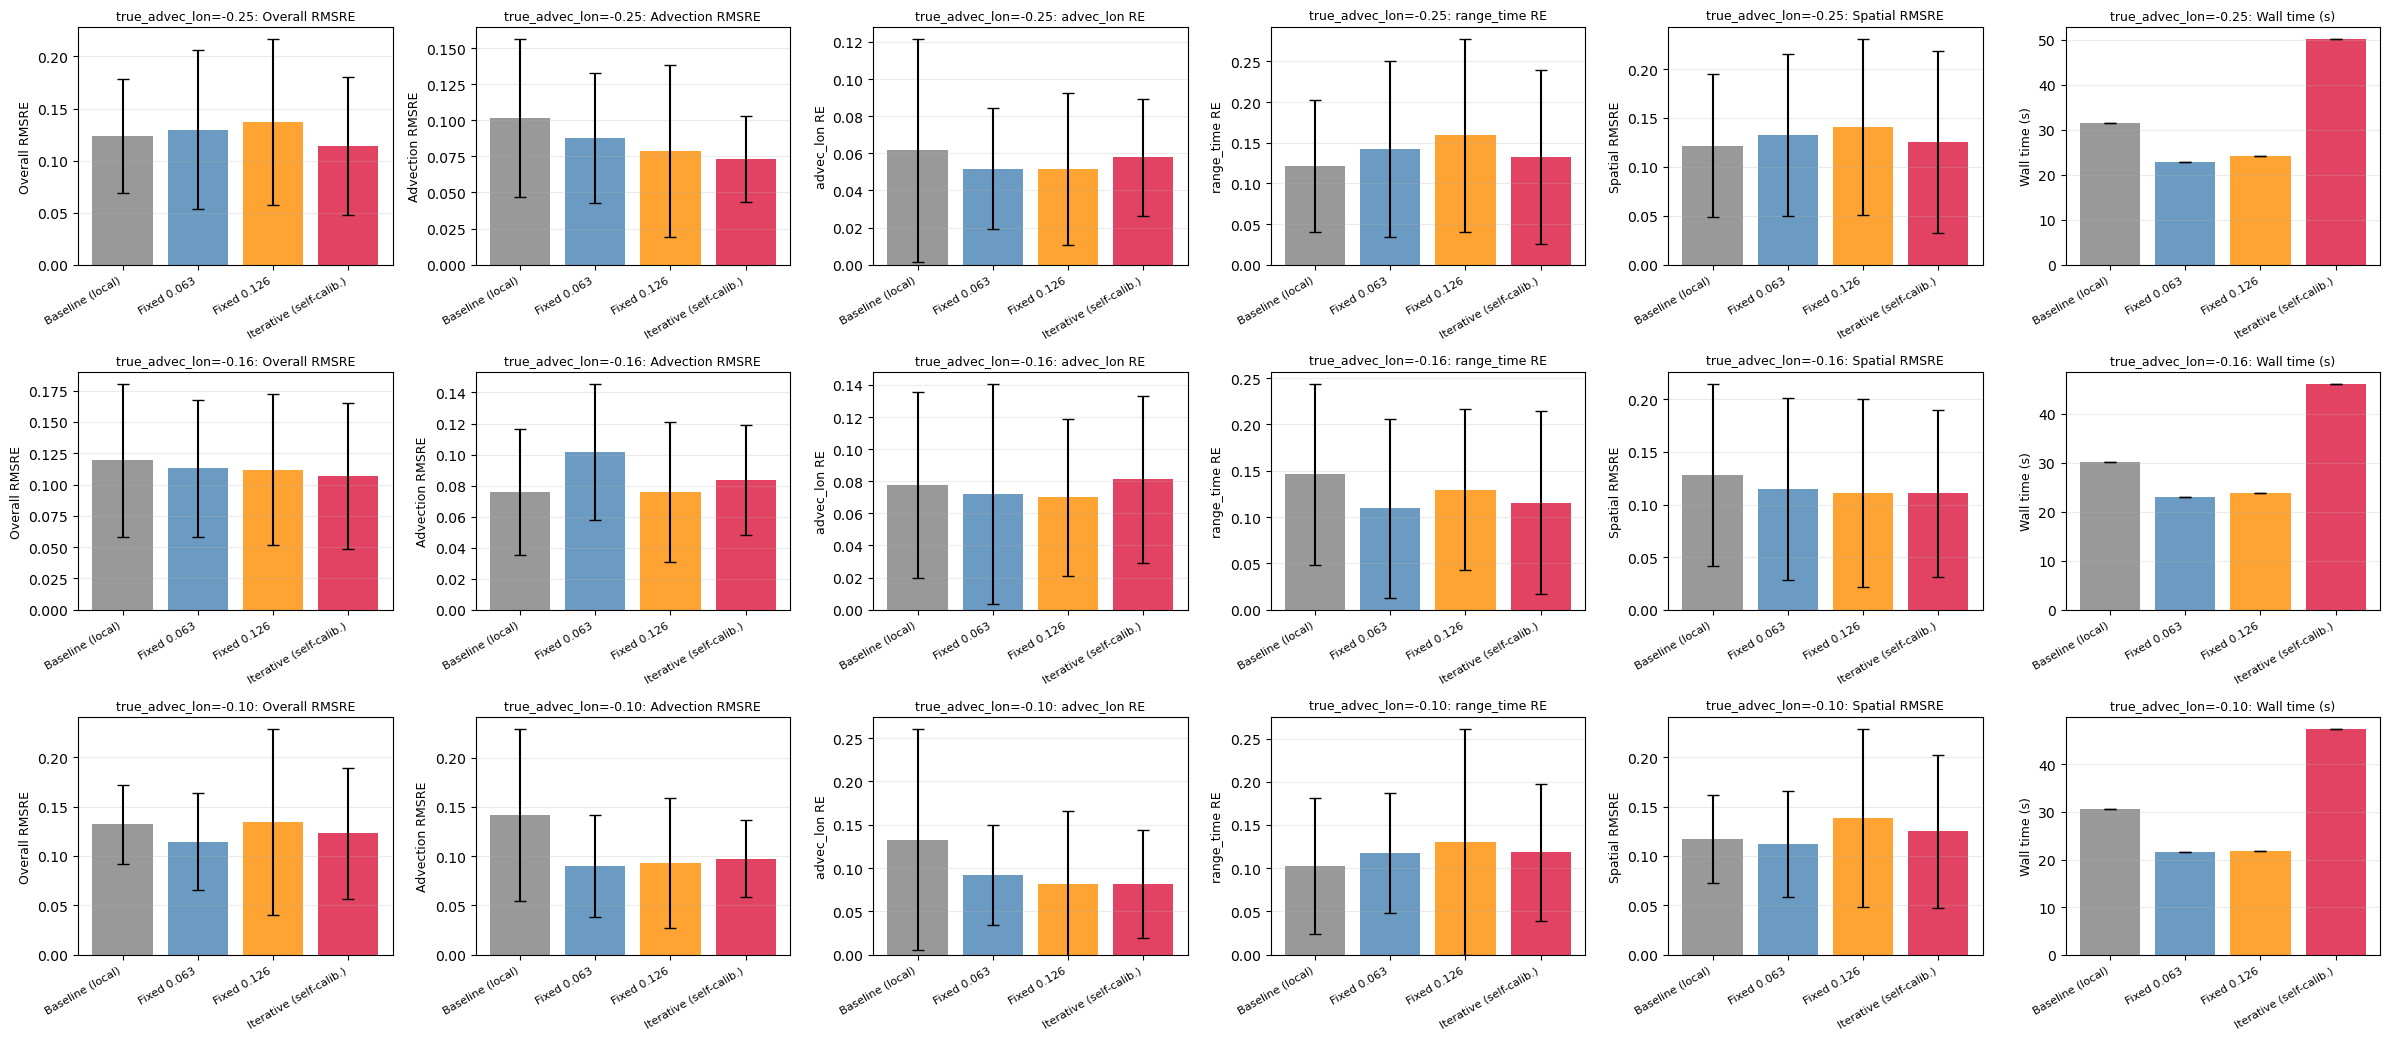

Saved: log/hybrid_iterative_model_comparison.png


In [12]:
MODEL_ORDER  = ["Irr_Baseline_A20_B18_C15",
                "Hybrid_Lean_Fixed_0p063",
                "Hybrid_Lean_Fixed_0p126",
                "Hybrid_Lean_Iterative"]
MODEL_COLORS = {"Irr_Baseline_A20_B18_C15":  "gray",
                "Hybrid_Lean_Fixed_0p063":    "steelblue",
                "Hybrid_Lean_Fixed_0p126":    "darkorange",
                "Hybrid_Lean_Iterative":      "crimson"}
MODEL_LABELS = {"Irr_Baseline_A20_B18_C15":  "Baseline (local)",
                "Hybrid_Lean_Fixed_0p063":    "Fixed 0.063",
                "Hybrid_Lean_Fixed_0p126":    "Fixed 0.126",
                "Hybrid_Lean_Iterative":      "Iterative (self-calib.)"}

metrics_to_plot = [
    ("overall_rmsre_mean",   "overall_rmsre_p90_p10",  "Overall RMSRE"),
    ("advec_rmsre_mean",     "advec_rmsre_p90_p10",    "Advection RMSRE"),
    ("advec_lon_re_mean",    "advec_lon_re_p90_p10",   "advec_lon RE"),
    ("range_time_re_mean",   "range_time_re_p90_p10",  "range_time RE"),
    ("spatial_rmsre_mean",   "spatial_rmsre_p90_p10",  "Spatial RMSRE"),
    ("total_s_mean",         None,                     "Wall time (s)"),
]

scenarios = sorted(mc_summary["true_advec_lon"].unique())
n_scen    = len(scenarios)
n_metrics = len(metrics_to_plot)

fig, axes = plt.subplots(n_scen, n_metrics, figsize=(4 * n_metrics, 3.5 * n_scen), squeeze=False)

for row_i, ta in enumerate(scenarios):
    sub = mc_summary[mc_summary["true_advec_lon"] == ta]
    x   = np.arange(len(MODEL_ORDER))
    for col_j, (mean_col, spread_col, label) in enumerate(metrics_to_plot):
        ax = axes[row_i][col_j]
        for xi, mdl in enumerate(MODEL_ORDER):
            row_df = sub[sub["model"] == mdl]
            if row_df.empty:
                continue
            val  = float(row_df[mean_col].iloc[0])
            yerr = (float(row_df[spread_col].iloc[0]) / 2.0
                    if spread_col and spread_col in row_df.columns else 0.0)
            ax.bar(xi, val, color=MODEL_COLORS.get(mdl, "steelblue"),
                   yerr=yerr, capsize=4, alpha=0.8,
                   label=MODEL_LABELS.get(mdl, mdl))
        ax.set_xticks(x)
        ax.set_xticklabels([MODEL_LABELS.get(m, m) for m in MODEL_ORDER],
                           rotation=30, ha="right", fontsize=8)
        ax.set_ylabel(label, fontsize=9)
        ax.set_title(f"true_advec_lon={ta:.2f}: {label}", fontsize=9)
        ax.grid(axis="y", alpha=0.25)
        ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("log/hybrid_iterative_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: log/hybrid_iterative_model_comparison.png")

## Offset Convergence Trajectory

In [13]:
iter_df = df_mc[(df_mc["model"] == "Hybrid_Lean_Iterative") &
                df_mc["error"].isna()].copy() if "error" in df_mc.columns else \
          df_mc[df_mc["model"] == "Hybrid_Lean_Iterative"].copy()

# Parse offset_history_str → trajectory rows
traj_rows = []
for _, r in iter_df.iterrows():
    hist_str = str(r.get("offset_history_str", ""))
    hist     = [float(x) for x in hist_str.split("|") if x]
    for step_i, off in enumerate(hist):
        traj_rows.append({
            "iter":           r["iter"],
            "true_advec_lon": r["true_advec_lon"],
            "outer_step":     step_i,
            "offset":         off,
            "n_outer_iters":  r["n_outer_iters"],
            "final_offset":   r["final_offset"],
        })
traj_df = pd.DataFrame(traj_rows)

print("Offset convergence summary by true_advec_lon:")
display(traj_df.groupby(["true_advec_lon", "outer_step"])["offset"].agg(["mean", "median", "std"]).round(4))

Offset convergence summary by true_advec_lon:


mean  median     std
true_advec_lon outer_step                        
-0.25          0           0.0630  0.0630  0.0000
               1           0.2498  0.2542  0.0168
               2           0.2457  0.2408  0.0169
               3           0.2456  0.2409  0.0169
               4           0.2439  0.2402  0.0100
-0.16          0           0.0630  0.0630  0.0000
               1           0.1635  0.1602  0.0146
               2           0.1635  0.1638  0.0143
               3           0.1623  0.1637  0.0149
               4           0.1701  0.1701     NaN
-0.10          0           0.0630  0.0630  0.0000
               1           0.0968  0.0944  0.0103
               2           0.0935  0.0938  0.0075
               3           0.0971  0.0972  0.0092
               4           0.0945  0.0945  0.0136

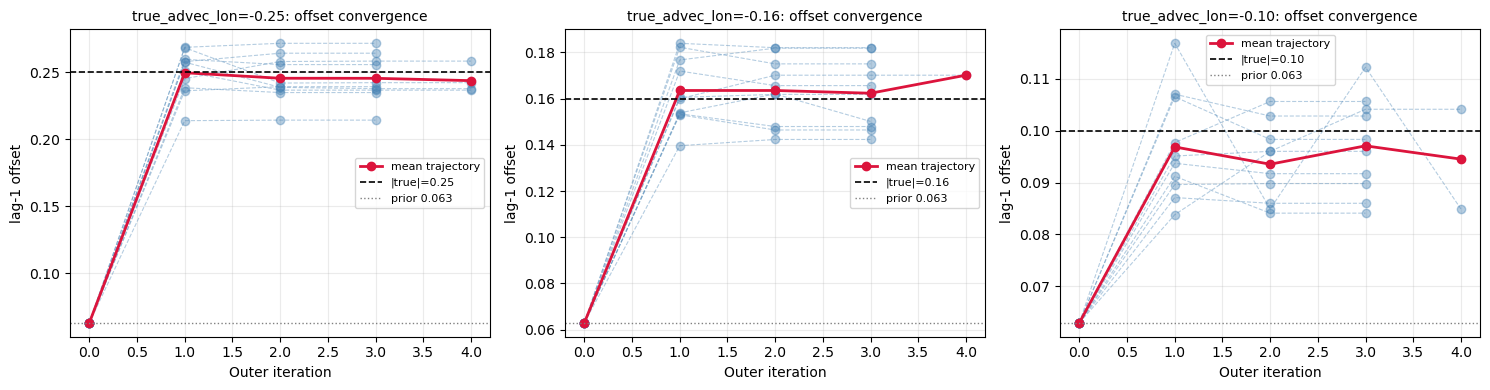

Saved: log/hybrid_iterative_offset_trajectory.png


In [14]:
scenarios = sorted(traj_df["true_advec_lon"].unique())
fig, axes = plt.subplots(1, len(scenarios), figsize=(5 * len(scenarios), 4), squeeze=False)

for col_j, ta in enumerate(scenarios):
    ax  = axes[0][col_j]
    sub = traj_df[traj_df["true_advec_lon"] == ta]
    for it_id, grp in sub.groupby("iter"):
        ax.plot(grp["outer_step"], grp["offset"], "o--", alpha=0.4, color="steelblue", linewidth=0.8)
    # mean trajectory
    mean_traj = sub.groupby("outer_step")["offset"].mean()
    ax.plot(mean_traj.index, mean_traj.values, "o-", color="crimson", linewidth=2.0,
            label="mean trajectory")
    ax.axhline(abs(ta), color="black", linestyle="--", linewidth=1.2, label=f"|true|={abs(ta):.2f}")
    ax.axhline(0.063, color="gray", linestyle=":", linewidth=1.0, label="prior 0.063")
    ax.set_xlabel("Outer iteration", fontsize=10)
    ax.set_ylabel("lag-1 offset",    fontsize=10)
    ax.set_title(f"true_advec_lon={ta:.2f}: offset convergence", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("log/hybrid_iterative_offset_trajectory.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: log/hybrid_iterative_offset_trajectory.png")

## Speed: Iterative vs Fixed

In [15]:
time_summary = mc_summary[["model", "iterative", "total_s_mean",
                            "n_outer_iters_mean"]].drop_duplicates(subset="model")
time_summary = time_summary[time_summary["model"].isin(MODEL_ORDER)].set_index("model")
baseline_t   = float(time_summary.loc["Hybrid_Lean_Fixed_0p063", "total_s_mean"])
time_summary["slowdown_vs_fixed063"] = time_summary["total_s_mean"] / baseline_t
display(time_summary[["total_s_mean", "n_outer_iters_mean", "slowdown_vs_fixed063"]].round(3))

,total_s_mean,n_outer_iters_mean,slowdown_vs_fixed063
model,,,
Irr_Baseline_A20_B18_C15,30.702,1.0,1.422
Hybrid_Lean_Fixed_0p063,21.595,1.0,1.000
Hybrid_Lean_Fixed_0p126,21.889,1.0,1.014
Hybrid_Lean_Iterative,47.500,3.2,2.200


## Parameter Recovery Heatmap

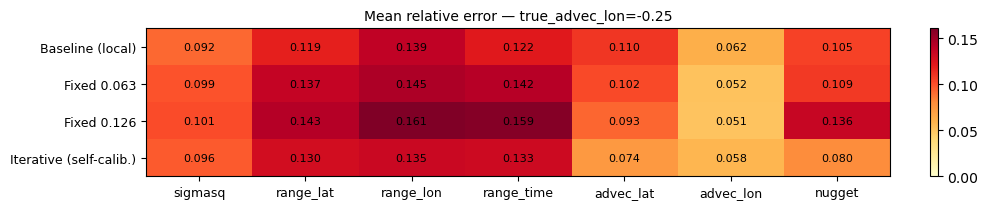

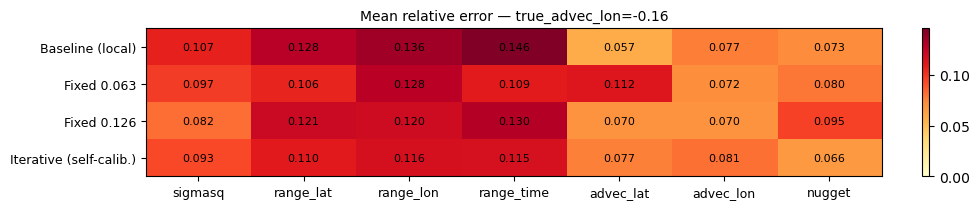

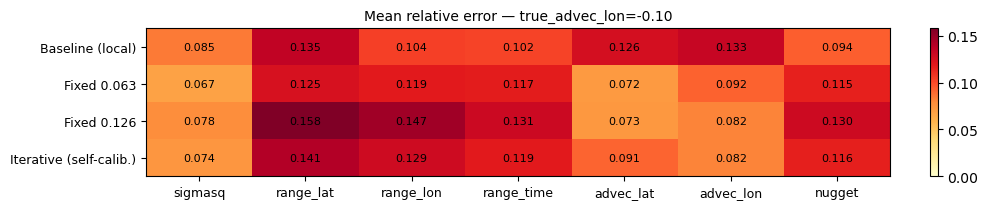

In [16]:
df_re = add_re_columns(df_mc.dropna(subset=["loss"]))
par_cols = ["sigmasq_re", "range_lat_re", "range_lon_re",
            "range_time_re", "advec_lat_re", "advec_lon_re", "nugget_re"]

agg = (
    df_re.groupby(["model", "true_advec_lon"])[par_cols]
    .mean()
    .reset_index()
)

for ta in sorted(agg["true_advec_lon"].unique()):
    sub = agg[agg["true_advec_lon"] == ta].set_index("model")[par_cols]
    sub = sub.reindex([m for m in MODEL_ORDER if m in sub.index])
    sub.columns = [c.replace("_re", "") for c in sub.columns]

    fig, ax = plt.subplots(figsize=(10, 2.2))
    im = ax.imshow(sub.values, aspect="auto", cmap="YlOrRd", vmin=0)
    ax.set_xticks(range(len(sub.columns)))
    ax.set_xticklabels(sub.columns, fontsize=9)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels([MODEL_LABELS.get(m, m) for m in sub.index], fontsize=9)
    for i in range(len(sub)):
        for j in range(len(sub.columns)):
            ax.text(j, i, f"{sub.values[i, j]:.3f}", ha="center", va="center",
                    fontsize=8, color="black")
    plt.colorbar(im, ax=ax, fraction=0.02)
    ax.set_title(f"Mean relative error — true_advec_lon={ta:.2f}", fontsize=10)
    plt.tight_layout()
    plt.savefig(f"log/hybrid_iterative_re_heatmap_advec{int(abs(ta)*100):03d}.png",
                dpi=120, bbox_inches="tight")
    plt.show()

## Interpretation

**Key questions:**

1. **Does iterative self-calibration improve over fixed 0.063?**  
   Check `advec_lon_re_mean` and `overall_rmsre_mean` for `Hybrid_Lean_Iterative` vs `Hybrid_Lean_Fixed_0p063`.

2. **Does iterative converge to a good offset?**  
   Offset trajectory plot — does the red mean trajectory approach `|true_advec_lon|` by outer_step 1–2?

3. **How much slower is iterative?**  
   Speed table `slowdown_vs_fixed063`. With warm-start + half-budget early iterations, expect 1.5–2× at most.

4. **Is fixed 0.126 already good enough?**  
   If `Fixed_0p126` beats `Iterative` on true_advec_lon=-0.16, the iterative loop may not be necessary for that scenario.

5. **Does iterative degrade at -0.10 (where true offset ≈ prior)?**  
   It shouldn't — warm-start should stay near 0.10 and converge quickly.